In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import pandas as pd
import matplotlib


plt.rcParams['image.interpolation'] = 'none'
plt.rcParams['image.aspect'] = 'auto'
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['legend.frameon'] = False
plt.rcParams['patch.edgecolor'] = 'none'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.formatter.limits'] = (-3,3)
plt.rcParams['path.simplify'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'
plt.style.use("seaborn-paper")

In [2]:
def plot_values(ax, data, valmax, valmin, dashed_line=False, odor=0):
    W=data.W.iloc[0]
    endzone = data.endzone.iloc[0].astype('int')
    T = data['T'].iloc[0]

    
    col = "green" if odor == 0 else "magenta"
    ax.plot(W[:, odor], color=col, ls='--' if dashed_line else '-')

    rtime = endzone > 0
    ptime = endzone < 0

    if odor == 0:
        ax.scatter(np.asarray(range(T))[rtime], valmax * np.ones(sum(rtime)) + .05 * dashed_line, color=col, s=3,  facecolors='none' if dashed_line else col)
    else:
        ax.scatter(np.asarray(range(T))[ptime], valmin * np.ones(sum(ptime)) + .01 * dashed_line, color=col, s=3, facecolors='none' if dashed_line else col)

def plot_values_by_compartment(ax1, ax2, data, dashed_line=False):
    def plot_values_by_compartment_aux(W_ap, W_av, ax1, i, odor_activation, dashed_line=False):
        apcol = '#E66100'
        avcol = '#5D3A9B'
        ax1.plot(0, 1, color=apcol, label=r'$w^{\mathrm{ap}}$' if i == 0 else "")
        ax1.plot(0, 1, color=avcol, label=r'$w^{\mathrm{av}}$' if i == 0 else "")
        ax1.plot(W_ap[:, odor_activation], color=apcol, ls='--' if dashed_line else '-')
        ax1.plot(W_av[:, odor_activation], color=avcol, ls='--' if dashed_line else '-')
    for i in range(len(data)):
        plot_values_by_compartment_aux(data.W_ap.iloc[i], data.W_av.iloc[i], ax1, i, data.odor_1_activation.iloc[i].astype('bool'), dashed_line=dashed_line)
        plot_values_by_compartment_aux(data.W_ap.iloc[i], data.W_av.iloc[i], ax2, i, data.odor_2_activation.iloc[i].astype('bool'), dashed_line=dashed_line)

In [9]:
df = pd.read_pickle('../local_data/non-agg-data.pkl')

/var/folders/tt/z91kvz8d6jj096mmy336sdz80000gn/T/ipykernel_57246/4083893325.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


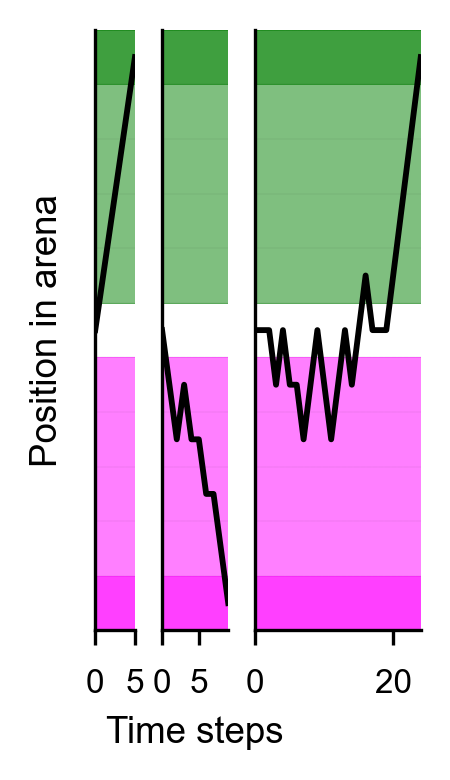

In [10]:
row = df[(df.protocol_type=='naturalistic') & ((df.seed==1)) &(df.bias_with=='none')].iloc[0]
trials = []
prev_end = 0
endzones = []
for end in np.nonzero(row.endzone)[0]:
    trials.append(list(row.s[prev_end:end+1]))
    endzones.append(row.endzone[end])
    prev_end = end +1

f, axs = plt.subplots(1,3, sharex=False, sharey='row', figsize=( 1.4, 2.6), gridspec_kw={'width_ratios': [len(trials[0]), len(trials[1]), len(trials[6])], 'wspace': .3})
next_ax = 0
for i, (trial, end) in enumerate(zip(trials, endzones)):
    if i in [0,1,6]:
        ax = axs[next_ax]
        next_ax+=1
        if (end == -1 and trial[-1]!=0) or (end == 1 and trial[-1]!=10) :
            trial = [10-t for t in trial] #10-t for t in trial
        y = list(range(len(trial)))
        ax.plot(y, trial, color = 'k')
        ax.set_ylim(-.5, 10.5)
        ax.set_xlim( min(y), max(y))
        ax.axvspan( min(y), max(y), ymin = 0, ymax = 5/11, color = 'magenta', alpha = .5)
        ax.axvspan(min(y), max(y), ymin = 6/11, ymax = 1, color = 'green', alpha = .5)
        ax.axvspan(min(y),max(y),  ymin = 0, ymax = 1/11, color = 'magenta', alpha = .5)
        ax.axvspan(min(y), max(y), ymin = 10/11, ymax = 1, color = 'green', alpha = .5)
        

        for j in range(11):
            ax.axhline(y=j + .5, xmin = 0, xmax = 1, color = 'k', ls = '--',  lw=.039, alpha = .5)
        if i == 0:
            ax.set_ylabel("Position in arena")
        if i == 1:
            ax.set_xlabel("Time steps")
        ax.set_yticks([],[])
        


plt.tight_layout()

plt.savefig('../figures/fig5c_example-trials.pdf', bbox_inches ='tight')



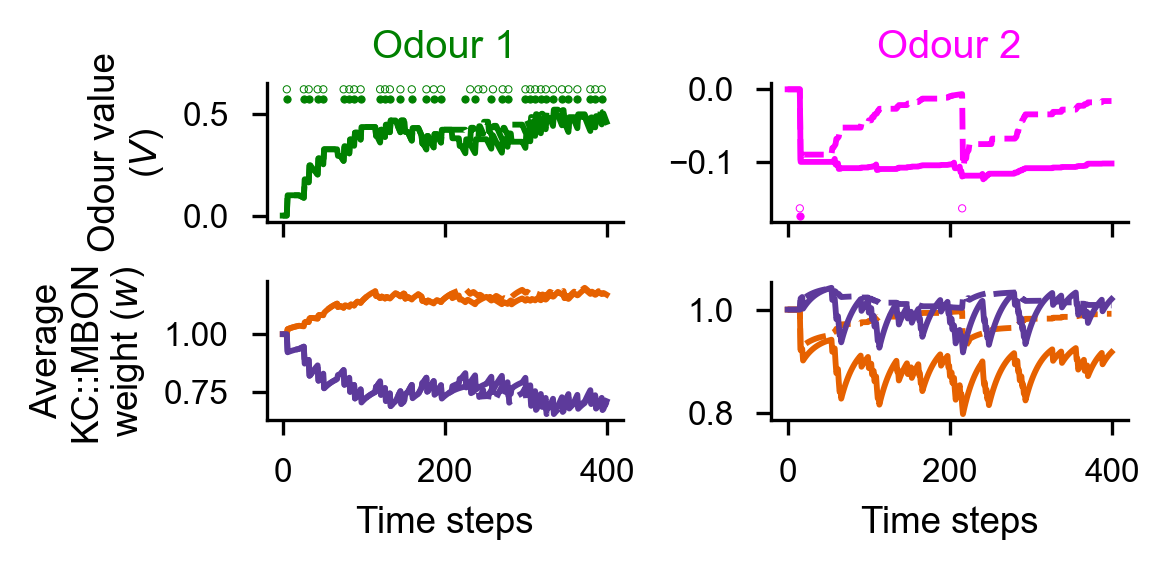

In [11]:
data = df[(df.protocol_type=='naturalistic') &(df.kc_subtractive_norm==True) & ((df.seed==1))&(df.bias_with!='action')]
f, axs = plt.subplots(2 ,2, sharex=True, sharey=False, figsize=(4,2))
plt.subplots_adjust(wspace=.6)
axs = np.asarray([[axs[0,0], axs[1,0], axs[0,1], axs[1,1]]]).T
valmax = np.max(np.concatenate(list(data.W)))+.05
valmin = np.min(np.concatenate(list(data.W)))-.05
for i,(name, subdata) in enumerate(data.groupby('bias_with')):

    if name == 'value':
        name = 'With MDN feedback'
        i=1
    else:
        name = 'No MDN feedback'
        i = 0
    
    plot_values_by_compartment(axs[1,0], axs[3,0], subdata,1-i)
    plot_values(axs[0,0], subdata, valmax, valmin,1-i, odor=0)
    plot_values(axs[2,0], subdata, valmax, valmin, 1-i,odor = 1)
    if i ==0:
        axs[0,0].set_ylabel("Odour value\n"+( r"($V$)"))
        axs[0,0].set_title("Odour 1", color = 'green')

        axs[0,0].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axs[2,0].set_title("Odour 2", color='magenta')
        axs[1,0].set_ylabel("Average\nKC::MBON\nweight " + r"($w$)" )
    axs[1,0].set_xlabel("Time steps")
    axs[3,0].set_xlabel("Time steps")

plt.tight_layout()

plt.savefig('../figures/fig5d_model-over-multiple-trials.pdf', bbox_inches ='tight')

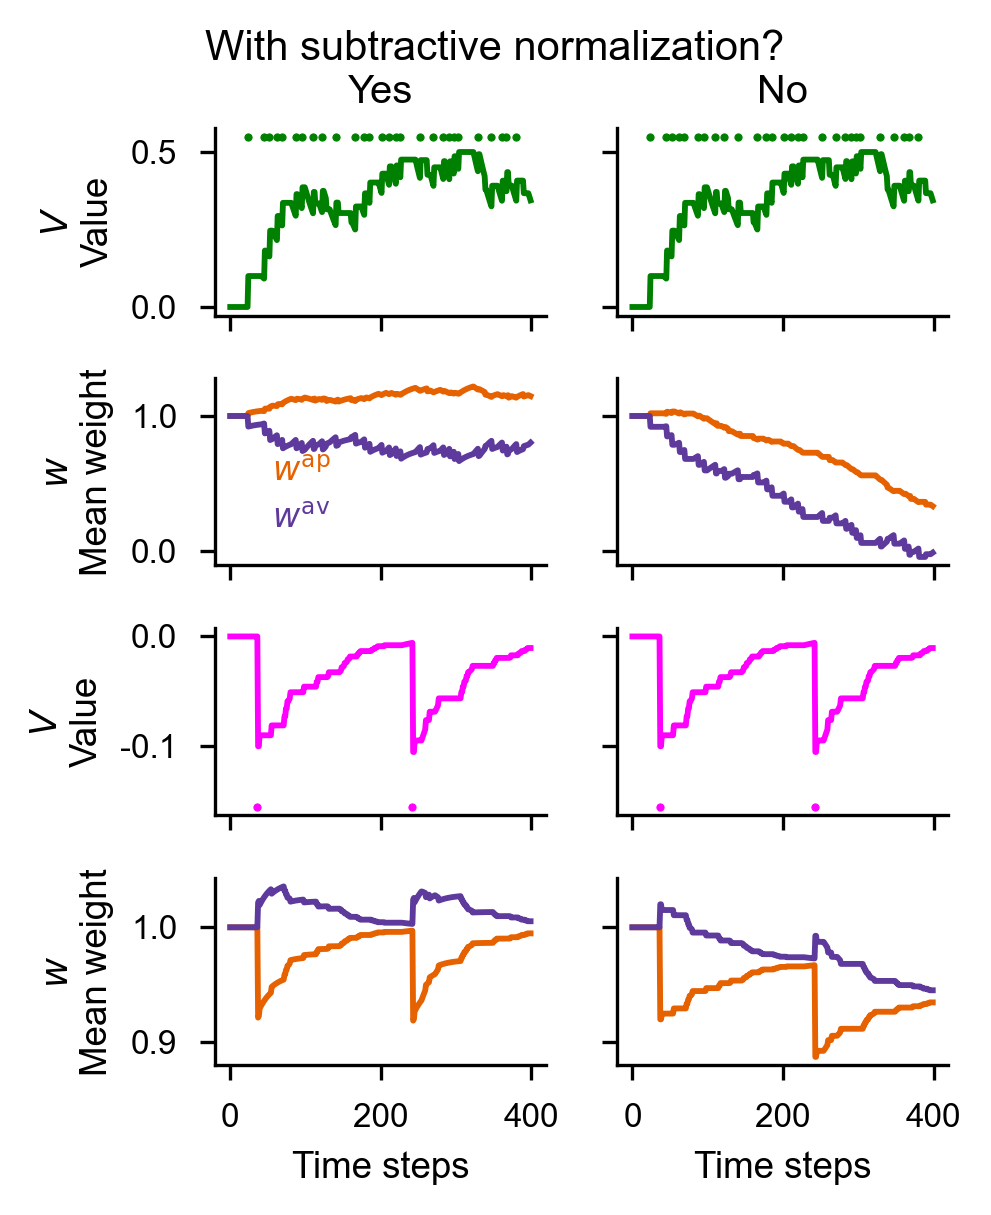

In [12]:
data = df[(df.protocol_type=='naturalistic') & ((df.seed==10))&(df.bias_with == 'none')]
f, axs = plt.subplots(4 ,2, sharex=True, sharey='row', figsize=(3.4,4))#, figsize=(6,6))

valmax = np.max(np.concatenate(list(data.W)))+.05
valmin = np.min(np.concatenate(list(data.W)))-.05
for i,(name, subdata) in enumerate(data.groupby('kc_subtractive_norm')):
    if name :
        name = 'Yes'
        i = 0
    else:
        name = 'No'
        i = 1
    plot_values_by_compartment(axs[1,i], axs[3,i], subdata, dashed_line=False)
    plot_values(axs[0,i], subdata, valmax, valmin, odor=0)
    plot_values(axs[2,i], subdata, valmax, valmin, odor=1)
    if i ==0:
        for j in range(4):
            axs[j,i].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axs[0,i].set_ylabel(r'$V$' + "\nValue")
        axs[2,i].set_ylabel(r'$V$' + "\nValue")
        
        axs[1,i].set_ylabel(r"$w$" + "\nMean weight")
        axs[3,i].set_ylabel(r"$w$" + "\nMean weight")
        leg = axs[1,i].legend(handlelength=0, loc='lower left')
        for line,text in zip(leg.get_lines(), leg.get_texts()):
            text.set_color(line.get_color())
        for line,text in zip(leg.get_lines(), leg.get_texts()):
            text.set_color(line.get_color())
    axs[3,i].set_xlabel("Time steps")
    axs[0,i].set_title(name)#("silence " +  silence + "s") if silence else "no silencing")

plt.tight_layout()
plt.suptitle("With subtractive normalization?", y = 1, fontsize=10)
plt.savefig('../figures/model-supplement_subtractive-normalization.pdf', bbox_inches ='tight')

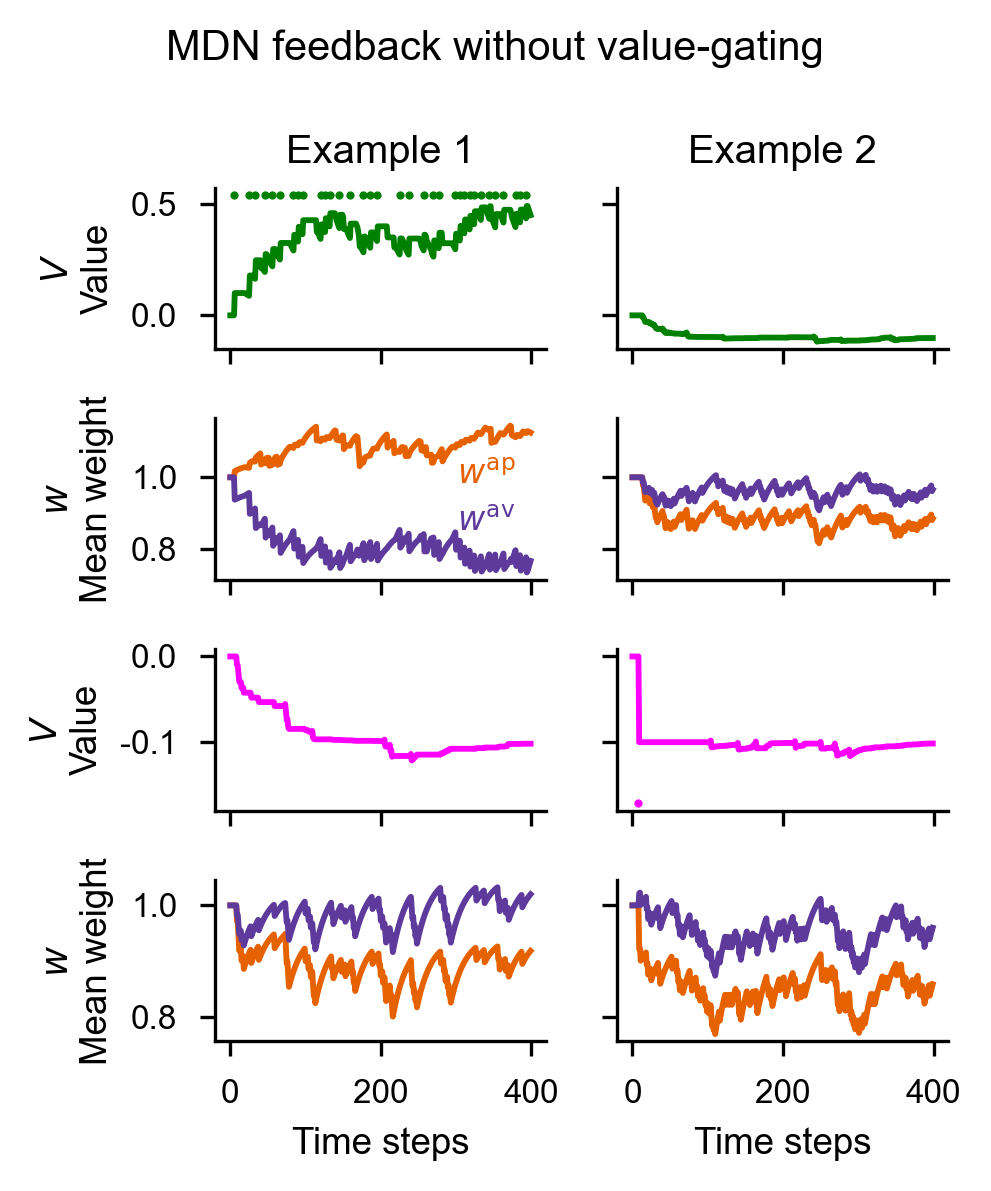

In [13]:
data = df[(df.protocol_type=='naturalistic')&(df.kc_subtractive_norm==True)  & ((df.seed==12)| (df.seed==1)) &(df.bias_with=='action')]
f, axs = plt.subplots(4,2, sharex=True, sharey='row', figsize=(3.4,4))
valmax = np.max(np.concatenate(list(data.W)))+.05
valmin = np.min(np.concatenate(list(data.W)))-.05
for i,(seed, subdata) in enumerate(data.groupby('seed')):
    if seed == 1:
        i = 0
        name = "Example 1"
    else:
        i=1
        name = "Example 2"


    plot_values_by_compartment(axs[1,i], axs[3,i], subdata, dashed_line=False)
    plot_values(axs[0,i], subdata, valmax, valmin, odor=0)
    plot_values(axs[2,i], subdata, valmax, valmin, odor = 1)
    if i ==0:
        for j in range(4):
            axs[j,i].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axs[0,i].set_ylabel(r'$V$' + "\nValue")
        axs[2,i].set_ylabel(r'$V$' + "\nValue")

        axs[1,i].set_ylabel(r"$w$" + "\nMean weight")
        axs[3,i].set_ylabel(r"$w$" + "\nMean weight")
        leg = axs[1,i].legend(handlelength=0)
        for line,text in zip(leg.get_lines(), leg.get_texts()):
            text.set_color(line.get_color())
    axs[3,i].set_xlabel("Time steps")
    axs[0,i].set_title(name)#("silence " +  silence + "s") if silence else "no silencing")
plt.suptitle("MDN feedback without value-gating", fontsize=10)
plt.tight_layout()

plt.savefig('../figures/model-supplement_without-value-gating.pdf', bbox_inches ='tight')

/var/folders/tt/z91kvz8d6jj096mmy336sdz80000gn/T/ipykernel_57246/2756126279.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['silence'] = data.apply(lambda x: condition_label(x),axis=1)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


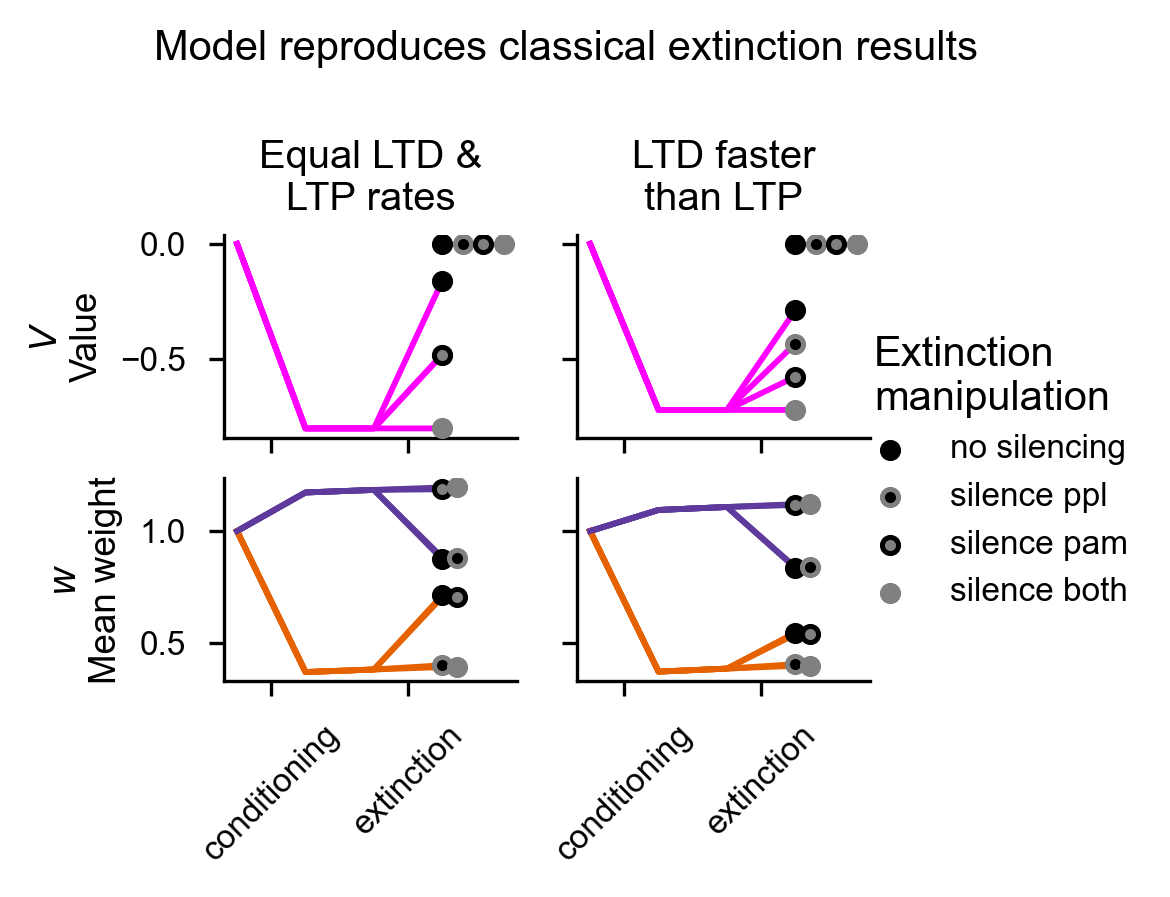

In [14]:
def condition_label(x):
    if x['silence ppls'] and x['silence pams']:
        return 'silence ppls and pams'
    elif x['silence ppls']:
        return 'silence ppls'
    elif x['silence pams']:
        return 'silence pams'
    else:
        return 'no silencing'
    
data['silence'] = data.apply(lambda x: condition_label(x),axis=1)
size_mult = 1.5
edge_mult = 1

def plot_extinction_values(ax, data, labelcolors):
    for i in range(len(data)):
        W = data.W.iloc[i]
        silence_ppl = data['silence ppls'].iloc[i]
        silence_pam = data['silence pams'].iloc[i]
        edgecolor = 'k'#'mediumpurple'
        fillcolor = 'k'#'aqua'
        if silence_ppl:
            edgecolor = 'grey'
        if silence_pam:
            fillcolor = 'grey'
        if silence_ppl and silence_pam:
            label = 'silence both'
        elif silence_ppl:
            label = 'silence ppl'
        elif silence_pam:
            label = 'silence pam'
        else:
            label = 'no silencing'


        pcol = "magenta"
        ax.plot(W[:,1], color = pcol)

        ax.scatter(3 + i*.2*size_mult ,W[-1,0], edgecolor = edgecolor, label = label if not labelcolors else "", s=10*size_mult, zorder=i+3, color = fillcolor,linewidth=1.2*edge_mult)
        ax.scatter(3,W[-1,1], edgecolor = edgecolor, s=10*size_mult, zorder=i+3, color = fillcolor, linewidth=1.2*edge_mult)

   



def plot_extinction_values_by_compartment(ax1, data):

    for i in range(len(data)):

        W_ap = data.W_ap.iloc[i]
        W_av = data.W_av.iloc[i]
        odor_2_activation = data.odor_2_activation.iloc[i].astype('bool')

        silence_ppl = data['silence ppls'].iloc[i]
        silence_pam = data['silence pams'].iloc[i]
        edgecolor = 'k'#'mediumpurple'
        fillcolor = 'k'#'aqua'
        if silence_ppl:
            edgecolor = 'grey'
        if silence_pam:
            fillcolor = 'grey'

        pstyle = "-"

        apcol = '#E66100'
        avcol = '#5D3A9B'


        
        ax1.plot(0,1, color = apcol, label = r'$w^{ap}$' if i == 0 else "")
        ax1.plot(0,1, color = avcol, label = r'$w^{av}$' if i==0 else "")
        


        ax1.plot(W_ap[:,odor_2_activation], color = apcol, ls = pstyle)
        ax1.plot(W_av[:,odor_2_activation], color = avcol, ls=pstyle)

        ax1.scatter(3 + (i//2)*.14*size_mult,W_ap[-1,odor_2_activation], edgecolor = edgecolor, s=10*size_mult, zorder=i+3, color = fillcolor,linewidth=1.2*edge_mult)
        ax1.scatter(3+ (i%2)*.14*size_mult,W_av[-1,odor_2_activation], edgecolor = edgecolor, s=10*size_mult, zorder=i+3, color = fillcolor, linewidth=1.2*edge_mult)


      


data = df[(df.protocol_type=='simple classical extinction')&(df.kc_subtractive_norm==True) & (df.seed == 0) & (df['bias_with'] == 'none') ]
f, axs = plt.subplots(2,2, sharex=True, sharey='row', figsize=(4,3))

plt.suptitle("Model reproduces classical extinction results", fontsize=10)
for i,(silence, subdata) in enumerate(data.groupby('learn_by_ltd_ltp')):
    if silence == (.8,.8):
        silence = "Equal LTD &\nLTP rates"
        i = 0
    else:
        i = 1
        silence = "LTD faster\nthan LTP"
    plot_extinction_values_by_compartment(axs[1,i], subdata)
    plot_extinction_values(axs[0,i], subdata, True if i == 0 else False)
    if i ==0:
        axs[0,i].set_ylabel(r"$V$"+"\nValue")
        axs[1,i].set_ylabel(r"$w$" + "\nMean weight")
        handles, labels = ax.get_legend_handles_labels()
        leg = axs[1,i].legend(reversed(handles), reversed(labels),handlelength=0)
        for line,text in zip(leg.get_lines(), leg.get_texts()):
            text.set_color(line.get_color())
        axs[0,i].legend()
    else:
        l = axs[0,i].legend(bbox_to_anchor=(.85, .65), title = "Extinction\nmanipulation")
    axs[1,i].set_xticks([.5, 2.5], ['conditioning', 'extinction'], rotation = 45)
    axs[0,i].set_title(silence)#("silence " +  silence + "s") if silence else "no silencing")


plt.tight_layout()
plt.subplots_adjust(hspace=.2)


plt.savefig('../figures/model-supplement_classical-extinction.pdf', bbox_inches ='tight')

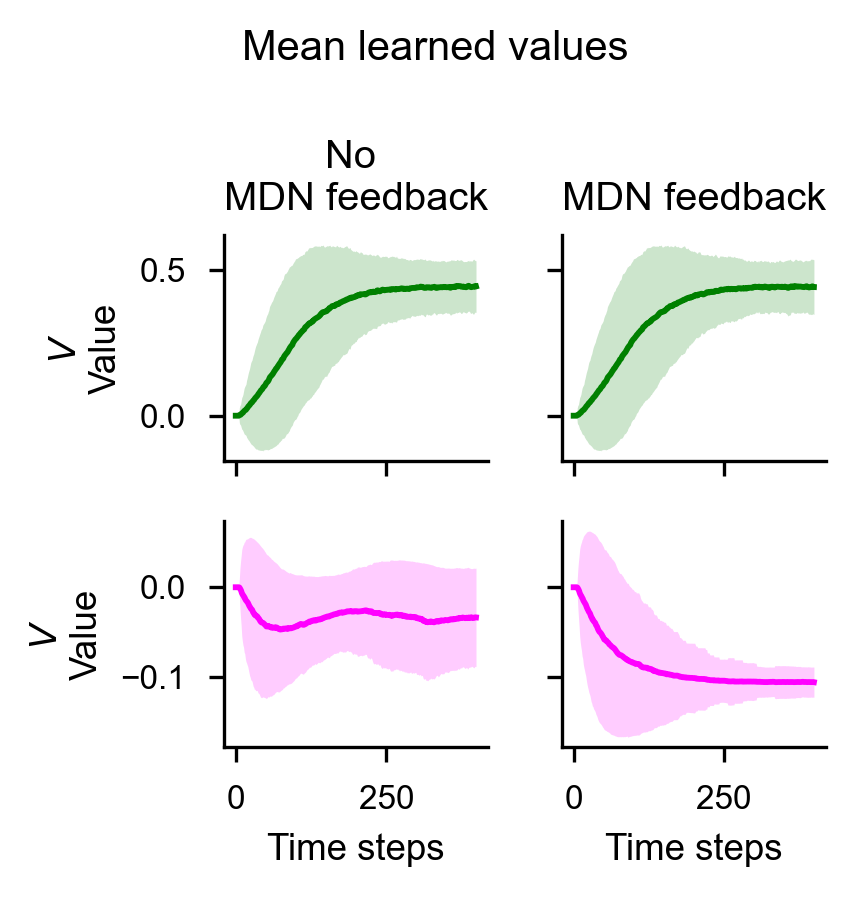

In [15]:

data = pd.read_pickle('../local_data/bulk-data.pkl')


def plot_mean_values(ax, data,  odor):
    
    W = np.dstack(data['W'])
    error = np.std(W, axis=2)
    W = np.mean(W, axis=2) # mean W

    col = "green" if odor == 0 else "magenta"
    error = 2*error
    ax.plot(W[:,odor], color = col)
    ax.fill_between(range(len(W[:,odor])), W[:,odor]-error[:,odor], W[:,odor]+error[:,odor], color = col, alpha = .2, linewidth=0.0)

f, axs = plt.subplots(2 ,2, sharex=True, sharey='row', figsize=(3,3))
for i,(name, subdata) in enumerate(data.groupby('bias_with')):
    if name == 'value':
        name = 'MDN feedback'
        i=1
    else:
        name = 'No \nMDN feedback'
        i = 0
        
    
    plot_mean_values(axs[0,i], subdata,  odor=0)
    plot_mean_values(axs[1,i], subdata,  odor = 1)
    if i ==0:
        axs[0,i].set_ylabel(r'$V$' + "\nValue")
        axs[1,i].set_ylabel(r'$V$' + "\nValue")
    axs[1 ,i].set_xlabel("Time steps")
    axs[0,i].set_title(name)
plt.suptitle("Mean learned values", fontsize=10)
plt.tight_layout()


plt.savefig('../figures/model-supplement_mean-learned-values-consistent.pdf', bbox_inches ='tight')

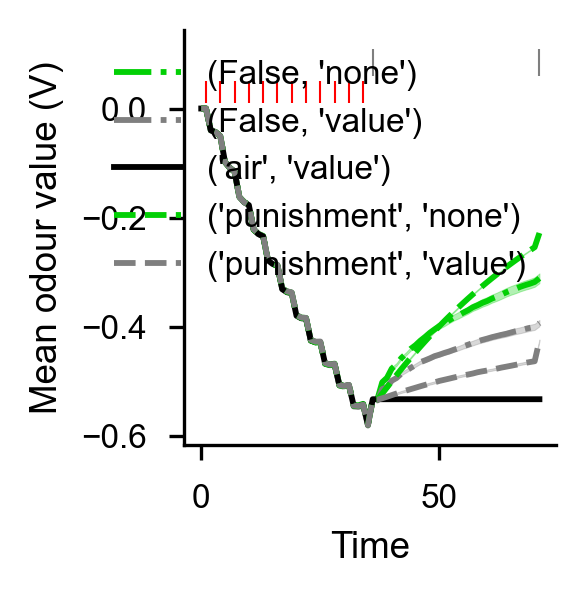

In [20]:
df = pd.read_pickle('../local_data/extinction-data.pkl' )
plt.figure(figsize=(1.6,1.8))
plt.vlines(np.where(df[df['trapped_extinction']=='punishment'].odor_state.iloc[0]==0)[0], .06,.11, color = 'k', alpha=.5, lw=.5, ls='-')
plt.vlines(np.where(df['r'].iloc[0]!=0), .01, .05, color='#ff0000ff', lw=.5, ls='-')
for name, data in df.groupby(['trapped_extinction', 'bias_with_extinction']):
    protocol, manipulation = name
    if protocol=="air":
        color = 'k'
        ls = '-'
    elif manipulation == 'none':
        color =  '#02d005ff'
    else:
        color = '#7f7f7fff'
    if protocol == 'punishment':
        ls = '--'
    elif protocol == False:
        ls = '-.'
    plt.plot(np.mean(np.vstack(data.Wfull), axis=0), label =name, color = color, ls = ls)
    plt.fill_between(range(len(data.Wfull.iloc[0])),np.mean(np.vstack(data.Wfull), axis=0)-2*np.std(np.vstack(data.Wfull), axis=0)/np.sqrt(len(data)), np.mean(np.vstack(data.Wfull), axis=0)+2*np.std(np.vstack(data.Wfull), axis=0)/np.sqrt(len(data)),  color = color,   alpha=.3)

plt.legend()
plt.ylabel('Mean odour value ' + r'(V)')
plt.xlabel('Time')
plt.savefig('../figures/fig5e_value-extinction.svg')
plt.show()

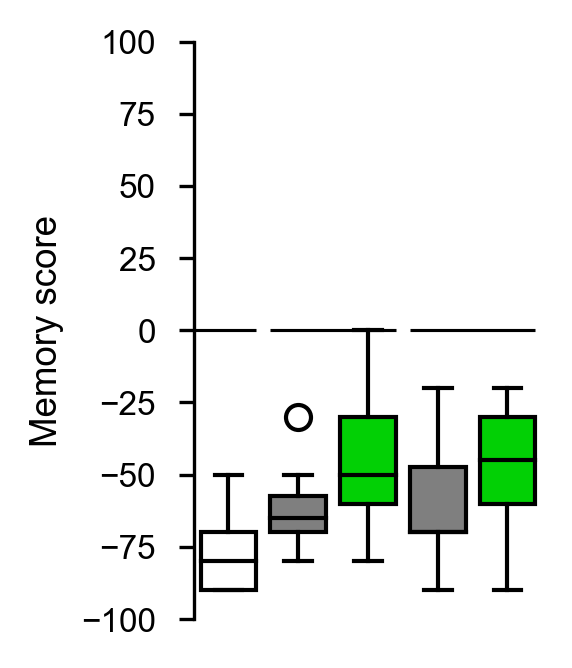

In [22]:
def calculate_pi(x):
    return (np.sum(x==1) - np.sum(x==0))/(np.sum(x==1) + np.sum(x==0))
PI_df = df[['trapped_extinction', 'bias_with_extinction', 'experiment_group', 'choice']].groupby(['trapped_extinction', 'bias_with_extinction', 'experiment_group']).agg(lambda x: calculate_pi(x)*100).reset_index()

protocol_dict = {
    False: 'air vs. odor',
    'air': 'air vs. air',
    'punishment': 'odor vs. odor'
}
moonwalker_dict = {
    'value': 'yes',
    'none': 'no'
}

PI_df['protocol'] = PI_df.trapped_extinction.apply(lambda x: protocol_dict[x])
PI_df['is moonwalker intact?'] = PI_df.bias_with_extinction.apply(lambda x: moonwalker_dict[x])
PI_df.drop(['trapped_extinction', 'bias_with_extinction', 'experiment_group'],axis=1).to_excel('../figures/fig5f-barchart-model-extinction-pi-independent-flies.xlsx')


matplotlib.rcParams.update({'font.size': 9})
plt.figure(figsize=(1.5, 2.5))
bdf = [PI_df[PI_df['trapped_extinction']=='air'].choice, 
 PI_df[(PI_df['trapped_extinction']==False) &(PI_df.bias_with_extinction=='value')].choice,
 PI_df[(PI_df['trapped_extinction']==False) &(PI_df.bias_with_extinction=='none')].choice,
 PI_df[(PI_df['trapped_extinction']=='punishment') &(PI_df.bias_with_extinction=='value')].choice,
 PI_df[(PI_df['trapped_extinction']=='punishment') &(PI_df.bias_with_extinction=='none')].choice,]
            
bplot = plt.boxplot(bdf,
        patch_artist=True, # fill with color
        labels=['Baseline', 'Control', r'MDN1$^A$ silenced', 'Control', r'MDN1$^A$ silenced'],
        widths=.8)  # will be used to label x-ticks

for patch, color in zip(bplot['boxes'], ['white', '#7f7f7fff', '#02d005ff', '#7f7f7fff', '#02d005ff']):
    patch.set_facecolor(color)
for median in bplot['medians']:
    median.set_color('black')


plt.ylim(-100,100)
plt.ylabel('Memory score')
plt.xticks([],[])
# plt.hlines(0,.5,5.5, color='black')
plt.hlines(0,.5,1.4, color='black', linewidth=.75)
plt.hlines(0,1.6,3.4, color='black',linewidth=.75)
plt.hlines(0,3.6,5.4, color='black',linewidth=.75)
plt.gca().spines['bottom'].set_visible(False)



# plt.savefig('../figures/amin-et-al-extinction.svg', bbox_inches='tight', dpi=300)